In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

In [5]:
from sklearn.datasets import make_regression
X,y= make_regression(n_samples=4, n_features =1, n_targets=1,n_informative=1, noise = 80, random_state=13)

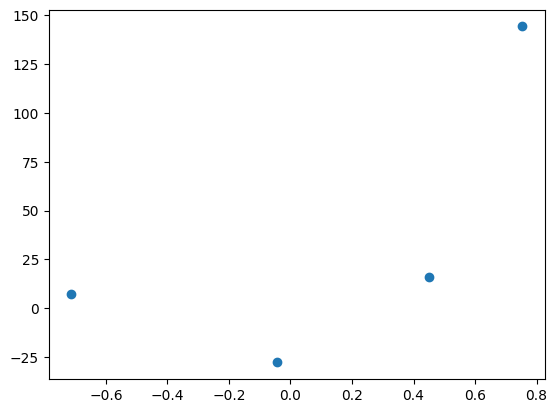

In [6]:
plt.scatter(X,y)

## Let's Apply the OLS

In [7]:
from sklearn.linear_model import LinearRegression
reg=LinearRegression()
reg.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
print(reg.coef_)
print(reg.intercept_)

[78.35063668]
26.15963284313262


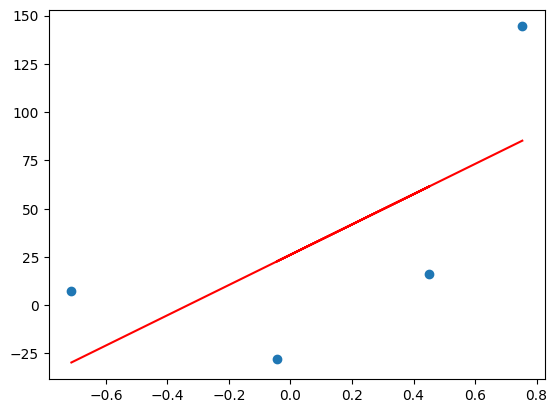

In [9]:
plt.scatter(X,y)
plt.plot(X,reg.coef_*X + reg.intercept_, color='red')

## Let's Apply the **Gradient Descent** assuming slope is constant m=78.35 and b=0

In [10]:
y_pred=(78.35*X+0).reshape(4)

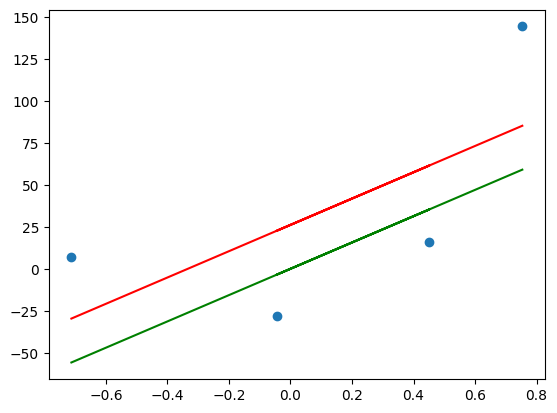

In [12]:
plt.scatter(X,y)
plt.plot(X,reg.coef_*X + reg.intercept_, color='red')
plt.plot(X, y_pred, color='green')

In [13]:
m=78.35
b=0

In [15]:
loss_slope=-2*np.sum(y-m*X.ravel() -b )

In [20]:
loss_slope

np.float64(-209.27763408209216)

In [ ]:
#learning rate 
lr=0.1
step_size=lr*loss_slope
b=b-step_size

In [19]:
b

np.float64(20.927763408209216)

In [17]:
y_pred1=((m*X)+b).reshape(4)

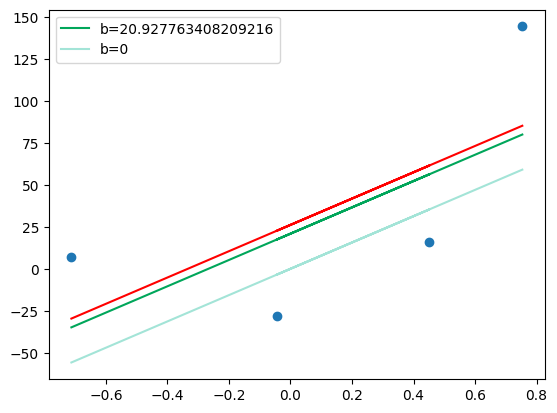

In [18]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X), color='red')
plt.plot(X, y_pred1, color='#00a65a', label='b={}'.format(b))
plt.plot(X,y_pred, color = '#A3E4D7', label='b=0')
plt.legend()
plt.show()


In [21]:
loss_slope=-2*np.sum(y-m*X.ravel() -b )
loss_slope

np.float64(-41.85552681641843)

In [22]:
b=b-lr*loss_slope
b

np.float64(25.11331608985106)

In [23]:
y_pred2=((m*X)+b).reshape(4)

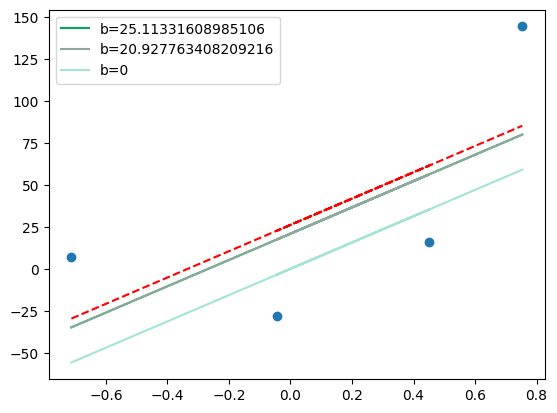

In [28]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X), color='red', linestyle='dashed' )
plt.plot(X, y_pred1, color='#00a65a', label='b={}'.format(b))
plt.plot(X, y_pred1, color="#8da89c", label='b={}'.format(20.927763408209216))
plt.plot(X,y_pred, color = '#A3E4D7', label='b=0')
plt.legend()
plt.show()

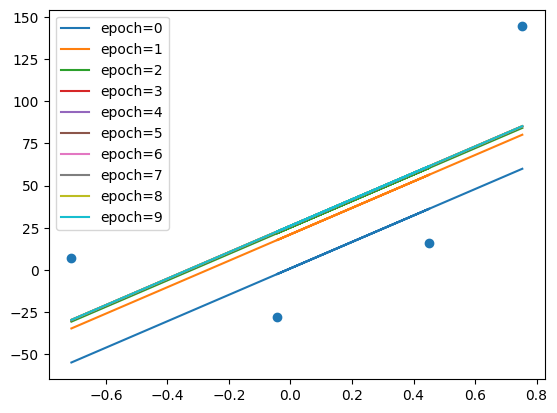

In [30]:
m=78.35
b=-100
lr=0.1
epoch=10

for i in range(epoch):
    loss_slope=-2*np.sum(y-m*X.ravel() -b)
    b=b-lr*loss_slope
    y_pred = ((m*X)+b).reshape(4)
    plt.plot(X,y_pred, label='epoch={}'.format(i))
    plt.legend()

plt.scatter(X,y)

## now I am creating the class that calculate the value of m and b using the gradient Descent...

In [66]:
X,y=make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20)

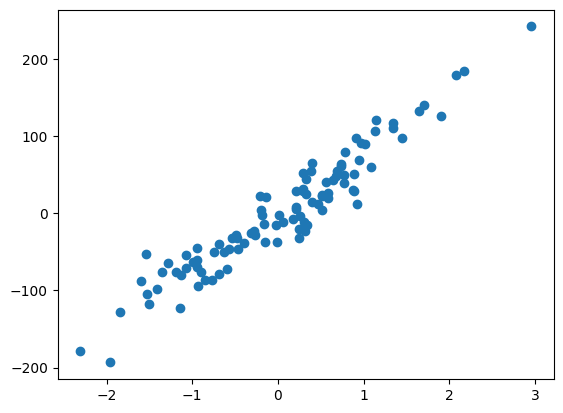

In [67]:
plt.scatter(X,y)

In [88]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2, random_state=13)

In [89]:
lr=LinearRegression()

In [90]:
lr.fit(X_train,y_train)
print(lr.coef_)
print(lr.intercept_)

[72.96665375]
-1.833222752397185


In [91]:
y_pred=lr.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.9598633210968595

In [92]:
class GDRegressor:
    def __init__(self, learning_rate, epochs,m,b):
        self.learning_rate = learning_rate
        self.epochs=epochs
        self.m=m
        self.b=b

    def fit(self, X,y):
        for i in range(self.epochs):
            loss_slope_b = -2*np.sum(y-self.m*X.ravel() - self.b)
            loss_slope_m = -2*np.sum(X.ravel()*(y-self.m*X.ravel() - self.b))
            self.b= self.b-self.learning_rate*loss_slope_b
            self.m= self.m-self.learning_rate*loss_slope_m
            print('epoch: {}, b: {}, m: {}'.format(i,self.b, self.m))
        print(self.m,self.b)
    
    def predict(self,X):
        return self.m*X + self.b


In [93]:
gd=GDRegressor(0.001, 50, m=120,b=10)

In [94]:
gd.fit(X_train,y_train)

epoch: 0, b: 7.93332653086094, m: 113.01229760653686
epoch: 1, b: 6.223076435116022, m: 107.06388947325529
epoch: 2, b: 4.808391290947799, m: 102.00001862372541
epoch: 3, b: 3.638720434930752, m: 97.68900099181846
epoch: 4, b: 2.6720866774171244, m: 94.0187809033366
epoch: 5, b: 1.8736421994368162, m: 90.89400150477485
epoch: 6, b: 1.2144663040515482, m: 88.23351304193895
epoch: 7, b: 0.6705647116019962, m: 85.96825345204857
epoch: 8, b: 0.22203677953360462, m: 84.03944555743998
epoch: 9, b: -0.1476173880773073, m: 82.39706349829997
epoch: 10, b: -0.45207331602370654, m: 80.99852813788934
epoch: 11, b: -0.7026615048481692, m: 79.80759720489328
epoch: 12, b: -0.9087659914542547, m: 78.79342106393025
epoch: 13, b: -1.0781556597324033, m: 77.92973936281699
epoch: 14, b: -1.217259580448534, m: 77.19419750942176
epoch: 15, b: -1.3313957773871172, m: 76.56776507995224
epoch: 16, b: -1.4249612472519249, m: 76.03424093767617
epoch: 17, b: -1.501589752324815, m: 75.57983211717915
epoch: 18, b: 

In [95]:
y_pred=gd.predict(X_test)
r2_score(y_test, y_pred)

0.9598919117648547

## Seeing visually all the changes

In [98]:
b=-120
m=100
lr=0.001
all_b=[]
all_m=[]
all_cost=[]

epochs=50
for i in range(epochs):
    loss_slope_b = -2*np.sum(y-m*X.ravel() - b)
    loss_slope_m = -2*np.sum(X.ravel()*(y-m*X.ravel() - b))
    cost=np.sum((y-m*X.ravel() -b)**2)

    b=b-lr*loss_slope_b
    m=m-lr*loss_slope_m
    all_b.append(b)
    all_m.append(m)
    all_cost.append(cost)

In [ ]:
#animation code
fig, ax = plt.subplots(figsize=(10,6))

x_i=np.arange(-3,3,0.1)
y_i=x_i*(-27)-150
ax.scatter(X,y)
line, = ax.plot(x_i,y_i,)